In [5]:
#####################################################
# Imports and Simulation IO
#####################################################
import os 
from MDToolkit.data.objects import Topology, Frame, Simulation, LAMMPS_CustomDump_Reader, MultiSimulation
from MDToolkit.data.misc_objects import BoxVolume
from MDToolkit.utils.structure_file_utils import create_elements_dictionary
from MDToolkit.analysis.dipole import system_dipole_moment, dipole_angle_distribution_timeaveraged
from MDToolkit.data.misc_objects import CylinderVolume

filedir = "/media/jrjoseph/Elements/projects/smaller_kcl_mos2_ls6/v1/"

# filenames = ["kcl_mos2_equilibration_run0.5.out", "kcl_mos2_equilibration_run1.25.out", "kcl_mos2_equilibration_run2.out", "kcl_mos2_equilibration_run2.75.out",
#              "kcl_mos2_equilibration_run3.5.out", "kcl_mos2_equilibration_run4.25.out", "kcl_mos2_equilibration_run5.out"]

# filepaths = [os.path.join(filedir, name) for name in filenames]

filename = "kcl_mos2_equilibration_run1.25.out"

filepath = os.path.join(filedir, filename)

type_mapping = {
    1 : "Mo",
    2 : "S",
    3 : "Cl",
    4 : "H",
    5 : "K",
    6 : "O"
}

charges_dict = {
    1 : 1.18,
    2 : -0.59,
    3 : -1.0,
    4 : 0.4238,
    5 : 1.0,
    6 : -0.8476
}

topol = Topology(type_mapping, elements_dict = create_elements_dictionary(), charges_dict = charges_dict)

# simulation = MultiSimulation(filepaths, topol, LAMMPS_CustomDump_Reader)
simulation = Simulation(filepath, topol, LAMMPS_CustomDump_Reader)

In [6]:
#####################################################
# Plotting Functions
#####################################################

import numpy as np
import matplotlib.pyplot as plt

def plot_dipole_moment(
    dipole_data,
    components=["x", "y", "z"],
    rolling_window=100,
    ax=None
):
    '''
    Plot the dipole moment vector components and/or magnitude as a function of time.
    '''

    if ax is None:
        fig, ax = plt.subplots()

    t = np.asarray(dipole_data["t"])
    mu = np.asarray(dipole_data["dipole_moment_vectors"])

    color_map = {
        "x": "C0",
        "y": "C1",
        "z": "C2",
        "magnitude": "k"
    }

    label_map = {
        "x": r"$\mu_x$",
        "y": r"$\mu_y$",
        "z": r"$\mu_z$",
        "magnitude": r"$|\mu|$"
    }

    component_map = {
        "x": 0,
        "y": 1,
        "z": 2
    }

    kernel = np.ones(rolling_window) / rolling_window

    for component in components:

        color = color_map[component]

        if component == "magnitude":
            values = np.linalg.norm(mu, axis=1)
        else:
            values = mu[:, component_map[component]]

        ax.scatter(
            t,
            values,
            s=8,
            color=color,
            alpha=0.15
        )

        if rolling_window > 1 and len(values) >= rolling_window:

            rolling_values = np.convolve(values, kernel, mode="valid")
            rolling_t = np.convolve(t, kernel, mode="valid")

            ax.plot(
                rolling_t,
                rolling_values,
                lw=2,
                color=color,
                label=f'{label_map[component]} ({rolling_window}-pt avg)'
            )
        else:
            ax.plot(
                t,
                values,
                lw=2,
                color=color,
                label=label_map[component]
            )

    ax.set_xlabel("Time Step")
    ax.set_ylabel(r"Dipole Moment ($e\cdot\mathrm{\AA}$)")

    ax.legend(
        frameon=False,
        ncol=min(len(components), 2),
        loc="best"
    )

    return ax

def plot_dipole_distribution(
    dipole_distribution_data,
    ax = None,
    color = "C0",
    label = None,
    show_std = True,
    show_gaussian = True
):
    '''
    Plot the block averaged dipole angle distribution with Gaussian fit.
    '''

    if ax is None:
        fig, ax = plt.subplots()

    x = np.asarray(dipole_distribution_data["angles"])
    y = np.asarray(dipole_distribution_data["probability"])
    std = np.asarray(dipole_distribution_data["std"])

    ax.plot(
        x,
        y,
        color = color,
        lw = 2,
        label = label
    )

    if show_std:

        ax.fill_between(
            x,
            y - std,
            y + std,
            color = color,
            alpha = 0.25
        )

    if show_gaussian:

        from scipy.optimize import curve_fit

        def gaussian(x, amplitude, mean, sigma):
            return amplitude * np.exp(
                -(x - mean)**2 / (2 * sigma**2)
            )

        valid = np.isfinite(y)

        popt, _ = curve_fit(
            gaussian,
            x[valid],
            y[valid],
            p0 = [
                np.max(y),
                x[np.argmax(y)],
                np.std(x)
            ]
        )

        gaussian_y = gaussian(
            x,
            *popt
        )

        ax.plot(
            x,
            gaussian_y,
            color = "C3",
            lw = 2,
            ls = "--",
            label = "Gaussian fit"
        )

    ax.set_xlabel(r"Dipole Angle (rad)")
    ax.set_ylabel(r"$P(\theta)$")

    if label is not None or show_gaussian:
        ax.legend(
            frameon = False,
            loc = "best"
        )

    return ax

In [ ]:
#####################################################
# Full System Dipole Temporal Evolution
#####################################################


data = system_dipole_moment(simulation)

In [ ]:
plot_dipole_moment(data, rolling_window = 100)
plt.show()

In [7]:
#####################################################
# Dipole Angle Distribution (Time Averaged)
#####################################################

vol = CylinderVolume([-4.0, 0.0, 0.0], [4.0, 0.0, 0.0], radius = 4.5)
n_bins = 100 
n_blocks = 10
ref_vec = [1.0, 0.0, 0.0]

data = dipole_angle_distribution_timeaveraged(simulation, ref_vec, vol, False, n_bins, n_blocks)

  0%|          | 0/751 [00:00<?, ?it/s]

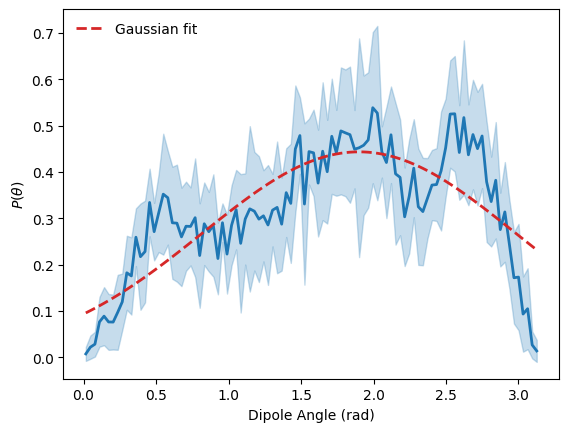

In [8]:
plot_dipole_distribution(data)
plt.show()